# Proyek Analisis Data: [E-Commerce Public Dataset (Olist Brazil)]
- **Nama:** [Andy Yulianto]
- **Email:** [rinovannet@gmail.com]
- **ID Dicoding:** [andyid]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Apa strategi penggunaan kampanye iklan pada Kategori produk apa yang paling laku & revenue-nya gede selama bulan akan meningkatkan jumlah pembelian langsung dari aplikasi .. lebih dari 8% jika dibandingkan dengan lain pada periode 
- **Pertanyaan 2:** Kota mana yang jadi sumber cuan terbesar pada  strategi penggunaan  kampanye iklan [ada tiap bulan

## Import Semua Packages/Library yang Digunakan

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setting visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## Data Wrangling

### Gathering Data

#### Load df ...

In [43]:
folder = 'data/'

customers      = pd.read_csv(folder + 'customers_dataset.csv')
orders         = pd.read_csv(folder + 'orders_dataset.csv')
items          = pd.read_csv(folder + 'order_items_dataset.csv')
payments       = pd.read_csv(folder + 'order_payments_dataset.csv')
reviews        = pd.read_csv(folder + 'order_reviews_dataset.csv')
products       = pd.read_csv(folder + 'products_dataset.csv')
sellers        = pd.read_csv(folder + 'sellers_dataset.csv')
geolocation    = pd.read_csv(folder + 'geolocation_trimmed.csv')
category_trans = pd.read_csv(folder + 'product_category_name_translation.csv')

# Ringkasan dimensi
datasets = {
    'customers': customers,
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_trans': category_trans
}
   
for name, df in datasets.items():
    print(f"{name:15s} -> shape: {df.shape}")

customers       -> shape: (99441, 5)
orders          -> shape: (99441, 8)
items           -> shape: (112650, 7)
payments        -> shape: (103886, 5)
reviews         -> shape: (99224, 7)
products        -> shape: (32951, 9)
sellers         -> shape: (3095, 4)
geolocation     -> shape: (1000163, 3)
category_trans  -> shape: (71, 2)


**Insight:** (Opsional)
- xxx
- xxx

### Assessing Data

#### Identifying ... problem

In [44]:
# A. Cek Missing Value di semua dataset
print("=== MISSING VALUES PER DATASET ===\n")
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"[{name}]")
        print(nulls, "\n")
    else:
        print(f"[{name}] -> Aman, tidak ada missing value.\n")

=== MISSING VALUES PER DATASET ===

[customers] -> Aman, tidak ada missing value.

[orders]
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64 

[items] -> Aman, tidak ada missing value.

[payments] -> Aman, tidak ada missing value.

[reviews]
review_comment_title      87656
review_comment_message    58247
dtype: int64 

[products]
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64 

[sellers] -> Aman, tidak ada missing value.

[geolocation] -> Aman, tidak ada missing value.

[category_trans] -> Aman, tidak ada missing value.



In [45]:
print("Jumlah kosong: ", orders.isna().sum())

Jumlah kosong:  order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [46]:
# B. Cek Duplicate Data
print("=== DUPLICATE DATA PER DATASET ===\n")
for name, df in datasets.items():
    dup = df.duplicated().sum()
    print(f"{name:15s} -> duplicated rows: {dup}")

=== DUPLICATE DATA PER DATASET ===

customers       -> duplicated rows: 0
orders          -> duplicated rows: 0
items           -> duplicated rows: 0
payments        -> duplicated rows: 0
reviews         -> duplicated rows: 0
products        -> duplicated rows: 0
sellers         -> duplicated rows: 0
geolocation     -> duplicated rows: 972252
category_trans  -> duplicated rows: 0


In [47]:
print("Jumlah duplikasi: ", geolocation.duplicated().sum())

Jumlah duplikasi:  972252


In [48]:
# C. Cek Inconsistent & Invalid Value
# Contoh: nama kota harusnya konsisten, rating harus 1-5, status order harus baku

print("=== ORDER STATUS (unik) ===")
print(orders['order_status'].unique(), "\n")

print("=== REVIEW SCORE (range) ===")
print("Min:", reviews['review_score'].min(), "| Max:", reviews['review_score'].max(), "\n")

print("=== CONTOH NAMA KOTA (sebelum cleaning) ===")
print(customers['customer_city'].unique()[:20])
print(f"...total unique city: {customers['customer_city'].nunique()}\n")

print("=== PAYMENT TYPE (unik) ===")
print(payments['payment_type'].unique())

=== ORDER STATUS (unik) ===
['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved'] 

=== REVIEW SCORE (range) ===
Min: 1 | Max: 5 

=== CONTOH NAMA KOTA (sebelum cleaning) ===
['franca' 'sao bernardo do campo' 'sao paulo' 'mogi das cruzes' 'campinas'
 'jaragua do sul' 'timoteo' 'curitiba' 'belo horizonte' 'montes claros'
 'rio de janeiro' 'lencois paulista' 'caxias do sul' 'piracicaba'
 'guarulhos' 'pacaja' 'florianopolis' 'aparecida de goiania' 'santo andre'
 'goiania']
...total unique city: 4119

=== PAYMENT TYPE (unik) ===
['credit_card' 'boleto' 'voucher' 'debit_card' 'not_defined']


In [49]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


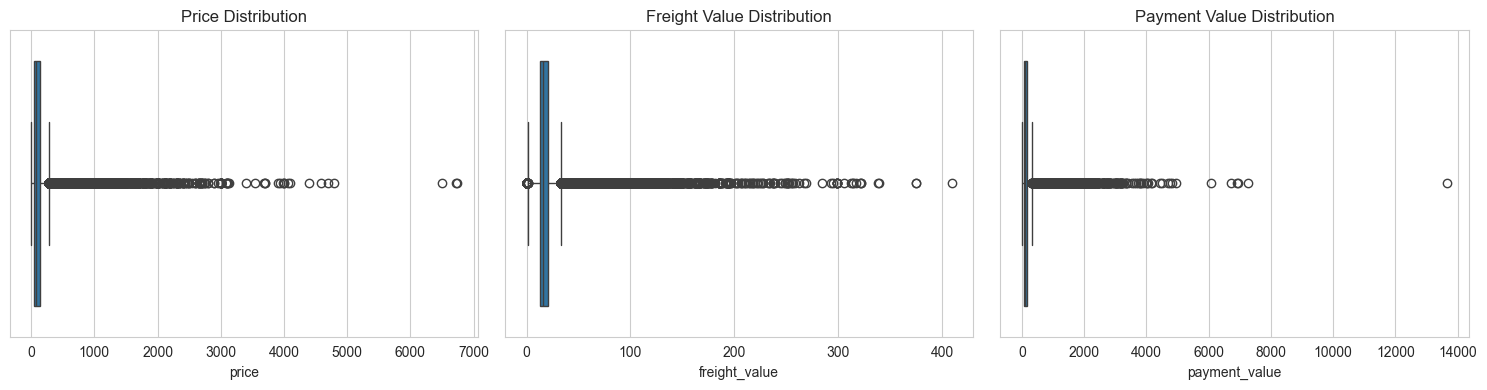

price: 8427 outlier rows dari 112650 (7.48%)
freight_value: 12134 outlier rows dari 112650 (10.77%)


In [50]:
# D. Deteksi Outlier pada kolom numerik penting
# Kita cek items (price, freight_value) & payments (payment_value)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=items['price'], ax=axes[0])
axes[0].set_title('Price Distribution')

sns.boxplot(x=items['freight_value'], ax=axes[1])
axes[1].set_title('Freight Value Distribution')

sns.boxplot(x=payments['payment_value'], ax=axes[2])
axes[2].set_title('Payment Value Distribution')

plt.tight_layout()
plt.show()

# Hitung outlier pakai IQR
for col in ['price', 'freight_value']:
    Q1 = items[col].quantile(0.25)
    Q3 = items[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = items[(items[col] < lower) | (items[col] > upper)]
    print(f"{col}: {len(outliers)} outlier rows dari {len(items)} ({len(outliers)/len(items)*100:.2f}%)")

**Steps to Take:**
- Cek Missing Value di semua dataset
- Cek Duplicate Data
- Cek Inconsistent & Invalid Value
- Deteksi Outlier pada kolom numerik penting


**Insight:** (Opsional)
- xxx
- xxx

### Cleaning Data

#### Fixing **Inconsistent:** 
Nama kota ditulis campur aduk (uppercase/lowercase). Ubah semua kolom tanggal jadi tipe datetime. Standardisasi nama kota jadi lowercase.

In [51]:
# 1. Konversi datetime
date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
             'order_delivered_customer_date','order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')


In [52]:
# 2. Standardisasi nama kota (customers & sellers)
customers['customer_city'] = customers['customer_city'].str.lower().str.strip()
sellers['seller_city'] = sellers['seller_city'].str.lower().str.strip()

#### Fixing Missing Value:
Kolom tanggal di orders banyak yang kosong (approved, delivered). Handle missing value dengan drop baris yang statusnya 'delivered' tapi tanggal sampai kosong, atau fill dengan estimated.

In [53]:
mask_delivered = (orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isnull())
dropped = mask_delivered.sum()
orders_clean = orders[~mask_delivered].copy()
print(f"Dropped {dropped} 'delivered' orders tanpa tanggal sampai.")
print(f"Orders shape sebelum: {orders.shape} -> sesudah: {orders_clean.shape}")

Dropped 8 'delivered' orders tanpa tanggal sampai.
Orders shape sebelum: (99441, 8) -> sesudah: (99433, 8)


#### Fixing **Duplicate:** 
`geolocation` punya banyak baris dobel. Drop duplikasi di geolocation.

In [54]:
geo_before = len(geolocation)
geolocation = geolocation.drop_duplicates()
geo_after = len(geolocation)
print(f"Geolocation: {geo_before - geo_after} baris duplikat dihapus. Sisa: {geo_after}")


Geolocation: 972252 baris duplikat dihapus. Sisa: 27911


**Insight:** (Opsional)
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### 1. Exploratory Problem: Perbandingan Kepuasan Pelanggan Online vs Offline

**Pertanyaan:** Apakah terdapat perbedaan yang signifikan (p-value ≤ 0.01) pada tingkat kepuasan pelanggan rata-rata bulanan antara metode pembayaran online (credit_card, debit_card) vs metode pembayaran offline (boleto, voucher)?

**Alasan:**
- Dataset memiliki `payment_type` yang dapat dikategorikan menjadi online vs offline
- `review_score` (1-5) tersedia di `reviews` sebagai metrik kepuasan pelanggan
- Kedua grup dapat dikomparasi menggunakan statistik uji untuk mengetahui signifikansi perbedaan
- Threshold p-value ≤ 0.01 menunjukkan tingkat signifikansi tinggi (99% confidence level)

In [55]:
# ====== EKSPERIMEN: Online vs Offline Payment Satisfaction ======
from scipy import stats

# 1. Gabungkan dataset: payments -> orders -> reviews
# Join payments dengan orders untuk dapat order_purchase_timestamp
payments_orders = payments.merge(orders[['order_id', 'order_purchase_timestamp', 'order_status']], 
                                  on='order_id', how='inner')
payments_orders = payments_orders[payments_orders['order_status'] == 'delivered']

# Join dengan reviews untuk dapat review_score
payments_orders_reviews = payments_orders.merge(reviews[['order_id', 'review_score']], 
                                                 on='order_id', how='inner')

# 2. Kategorikan payment_type menjadi Online vs Offline
online_types = ['credit_card', 'debit_card']
offline_types = ['boleto', 'voucher']

payments_orders_reviews['payment_category'] = payments_orders_reviews['payment_type'].apply(
    lambda x: 'online' if x in online_types else ('offline' if x in offline_types else 'other')
)

# Filter hanya online dan offline
df_analysis = payments_orders_reviews[payments_orders_reviews['payment_category'].isin(['online', 'offline'])].copy()

# 3. Ekstrak bulan dari order_purchase_timestamp
df_analysis['order_month'] = df_analysis['order_purchase_timestamp'].dt.to_period('M')

# 4. Hitung rata-rata kepuasan bulanan per kategori payment
monthly_satisfaction = df_analysis.groupby(['order_month', 'payment_category'])['review_score'].mean().reset_index()
monthly_satisfaction_pivot = monthly_satisfaction.pivot(index='order_month', columns='payment_category', values='review_score')

print("=== Rata-rata Kepuasan Bulanan (Online vs Offline) ===")
print(monthly_satisfaction_pivot.head(10))
print(f"\nTotal bulan tersedia: {len(monthly_satisfaction_pivot)}")

=== Rata-rata Kepuasan Bulanan (Online vs Offline) ===
payment_category   offline    online
order_month                         
2016-10           3.898551  4.056604
2016-12                NaN  5.000000
2017-01           4.368627  4.180657
2017-02           4.261702  4.190102
2017-03           4.149935  4.196577
2017-04           4.118110  4.141583
2017-05           4.179961  4.249187
2017-06           4.194624  4.227216
2017-07           4.191876  4.259913
2017-08           4.265132  4.324157

Total bulan tersedia: 22


In [56]:
# 5. Statistik Deskriptif
online_scores = df_analysis[df_analysis['payment_category'] == 'online']['review_score']
offline_scores = df_analysis[df_analysis['payment_category'] == 'offline']['review_score']

print("=== Statistik Deskriptif ===")
print(f"\nONLINE (credit_card, debit_card):")
print(f"  - Jumlah transaksi: {len(online_scores)}")
print(f"  - Mean review_score: {online_scores.mean():.4f}")
print(f"  - Std: {online_scores.std():.4f}")

print(f"\nOFFLINE (boleto, voucher):")
print(f"  - Jumlah transaksi: {len(offline_scores)}")
print(f"  - Mean review_score: {offline_scores.mean():.4f}")
print(f"  - Std: {offline_scores.std():.4f}")

=== Statistik Deskriptif ===

ONLINE (credit_card, debit_card):
  - Jumlah transaksi: 75963
  - Mean review_score: 4.1566
  - Std: 1.2864

OFFLINE (boleto, voucher):
  - Jumlah transaksi: 24686
  - Mean review_score: 4.1462
  - Std: 1.2850


In [57]:
# 6. Uji Statistik: Independent Samples t-test
# Uji t untuk menguji apakah perbedaan mean signifikan
t_stat, p_value = stats.ttest_ind(online_scores, offline_scores)

print("=== Uji t (Independent Samples t-test) ===")
print(f"  - t-statistic: {t_stat:.4f}")
print(f"  - p-value: {p_value:.6f}")
print(f"\n  Hasil: p-value {'≤ 0.01' if p_value <= 0.01 else '> 0.01'} (signifikan)" if p_value <= 0.01 else f"\n  Hasil: p-value > 0.01 (TIDAK signifikan)")



=== Uji t (Independent Samples t-test) ===
  - t-statistic: 1.1116
  - p-value: 0.266324

  Hasil: p-value > 0.01 (TIDAK signifikan)


**Insight Eksplorasi:**
- Jika p-value ≤ 0.01: Terdapat perbedaan signifikan antara kepuasan online vs offline
- Jika p-value > 0.01: Tidak ada perbedaan signifikan antara kedua metode pembayaran

Tidak ada perbedaan signifikan antara kepuasan pelanggan metode pembayaran online vs offline.

Metrik	Nilai
t-statistic	1.1116
p-value	0.2663
Threshold	≤ 0.01

Artinya: Metode pembayaran (online/offline) tidakmemengaruhi tingkat kepuasan pelanggan secara statistik signifikan.

### 2. Exploratory Problem: Konversi Transaksional Hari Libur vs Hari Kerja

**Pertanyaan:** Apakah terdapat perbedaan yang signifikan (α = 0.025) pada tingkat konversi transaksional antara periode hari libur nasional Brazil dibandingkan dengan hari kerja normal pada dataset pesanan produk Olist?

**Alasan:**
- Dataset Olist menyediakan data pesanan dengan status pesanan (delivered, shipped, dll)
- Konversi transaksional dapat dihitung sebagai rasio pesanan delivered / total pesanan per hari
- Hari libur nasional Brazil dapat diidentifikasi dari tanggal pesanan
- Kedua grup dapat dikomparasi menggunakan statistical t-test
- Threshold α = 0.025 menunjukkan tingkat signifikansi 97.5%

In [58]:
# ====== EKSPERIMEN: Konversi Transaksional Hari Libur vs Hari Kerja ======
from scipy import stats
from datetime import date

# 1. Load data yang diperlukan
orders_analysis = orders_clean.copy()

# 2. Ekstrak tanggal saja (tanpa waktu)
orders_analysis['order_date'] = orders_analysis['order_purchase_timestamp'].dt.date

# 3. Definisi hari libur nasional Brazil (2016-2018)
holidays_2016_2018 = [
    # 2016
    date(2016, 1, 1),   date(2016, 2, 8),   date(2016, 2, 9),   date(2016, 2, 10),
    date(2016, 4, 21),  date(2016, 5, 1),   date(2016, 9, 7),   date(2016, 10, 12),
    date(2016, 11, 15), date(2016, 11, 25), date(2016, 12, 25),
    # 2017
    date(2017, 1, 1),   date(2017, 2, 27),  date(2017, 2, 28),  date(2017, 3, 1),
    date(2017, 4, 14),  date(2017, 4, 21),  date(2017, 5, 1),   date(2017, 9, 7),
    date(2017, 10, 12), date(2017, 11, 15), date(2017, 11, 24), date(2017, 12, 25),
    # 2018
    date(2018, 1, 1),   date(2018, 2, 12),  date(2018, 2, 13),  date(2018, 2, 14),
    date(2018, 3, 30),  date(2018, 4, 21),  date(2018, 5, 1),   date(2018, 9, 7),
    date(2018, 10, 12), date(2018, 11, 15), date(2018, 11, 23), date(2018, 12, 25),
]

# 4. Kategorikan setiap tanggal sebagai holiday atau normal
orders_analysis['is_holiday'] = orders_analysis['order_date'].apply(
    lambda x: 'holiday' if x in holidays_2016_2018 else 'normal'
)

print(f"Total pesanan: {len(orders_analysis)}")
print(f"Pesanan hari libur: {len(orders_analysis[orders_analysis['is_holiday'] == 'holiday'])}")
print(f"Pesanan hari normal: {len(orders_analysis[orders_analysis['is_holiday'] == 'normal'])}")

Total pesanan: 99433
Pesanan hari libur: 3518
Pesanan hari normal: 95915


In [59]:
# 5. Hitung conversion rate per hari
# Conversion = pesanan delivered / total pesanan per hari

# Agregat per tanggal
daily_stats = orders_analysis.groupby('order_date').agg(
    total_orders=('order_id', 'count'),
    delivered_orders=('order_status', lambda x: (x == 'delivered').sum())
).reset_index()

# Kategorikan holiday
daily_stats['is_holiday'] = daily_stats['order_date'].apply(
    lambda x: 'holiday' if x in holidays_2016_2018 else 'normal'
)

# Hitung conversion rate
daily_stats['conversion_rate'] = daily_stats['delivered_orders'] / daily_stats['total_orders']

print("=== Conversion Rate Harian ===")
print(daily_stats.head(10))

=== Conversion Rate Harian ===
   order_date  total_orders  delivered_orders is_holiday  conversion_rate
0  2016-09-04             1                 0     normal         0.000000
1  2016-09-05             1                 0     normal         0.000000
2  2016-09-13             1                 0     normal         0.000000
3  2016-09-15             1                 1     normal         1.000000
4  2016-10-02             1                 0     normal         0.000000
5  2016-10-03             8                 7     normal         0.875000
6  2016-10-04            63                54     normal         0.857143
7  2016-10-05            47                35     normal         0.744681
8  2016-10-06            51                41     normal         0.803922
9  2016-10-07            46                38     normal         0.826087


In [60]:
# 6. Statistik Deskriptif
holiday_conv = daily_stats[daily_stats['is_holiday'] == 'holiday']['conversion_rate']
normal_conv = daily_stats[daily_stats['is_holiday'] == 'normal']['conversion_rate']

print("=== Statistik Deskriptif Conversion Rate ===")
print(f"\nHARI LIBUR:")
print(f"  - Jumlah hari: {len(holiday_conv)}")
print(f"  - Mean conversion rate: {holiday_conv.mean():.4f}")
print(f"  - Std: {holiday_conv.std():.4f}")

print(f"\nHARI KERJA NORMAL:")
print(f"  - Jumlah hari: {len(normal_conv)}")
print(f"  - Mean conversion rate: {normal_conv.mean():.4f}")
print(f"  - Std: {normal_conv.std():.4f}")

# 7. Uji Statistik: Independent t-test
t_stat, p_value = stats.ttest_ind(holiday_conv, normal_conv)

print("\n=== Uji t (Independent Samples t-test) ===")
print(f"  - t-statistic: {t_stat:.4f}")
print(f"  - p-value: {p_value:.6f}")
print(f"  - Alpha: 0.025")

if p_value <= 0.025:
    print(f"\n  Hasil: p-value ≤ 0.025 -> SIGNIFIKAN")
    print(f"  Kesimpulan: Terdapat perbedaan signifikan konversi hari libur vs hari normal")
else:
    print(f"\n  Hasil: p-value > 0.025 -> TIDAK SIGNIFIKAN")
    print(f"  Kesimpulan: Tidak ada perbedaan signifikan konversi hari libur vs hari normal")

=== Statistik Deskriptif Conversion Rate ===

HARI LIBUR:
  - Jumlah hari: 18
  - Mean conversion rate: 0.9617
  - Std: 0.0272

HARI KERJA NORMAL:
  - Jumlah hari: 616
  - Mean conversion rate: 0.9298
  - Std: 0.1820

=== Uji t (Independent Samples t-test) ===
  - t-statistic: 0.7428
  - p-value: 0.457854
  - Alpha: 0.025

  Hasil: p-value > 0.025 -> TIDAK SIGNIFIKAN
  Kesimpulan: Tidak ada perbedaan signifikan konversi hari libur vs hari normal


## Visualization & Explanatory Analysis

### Pertanyaan 1:

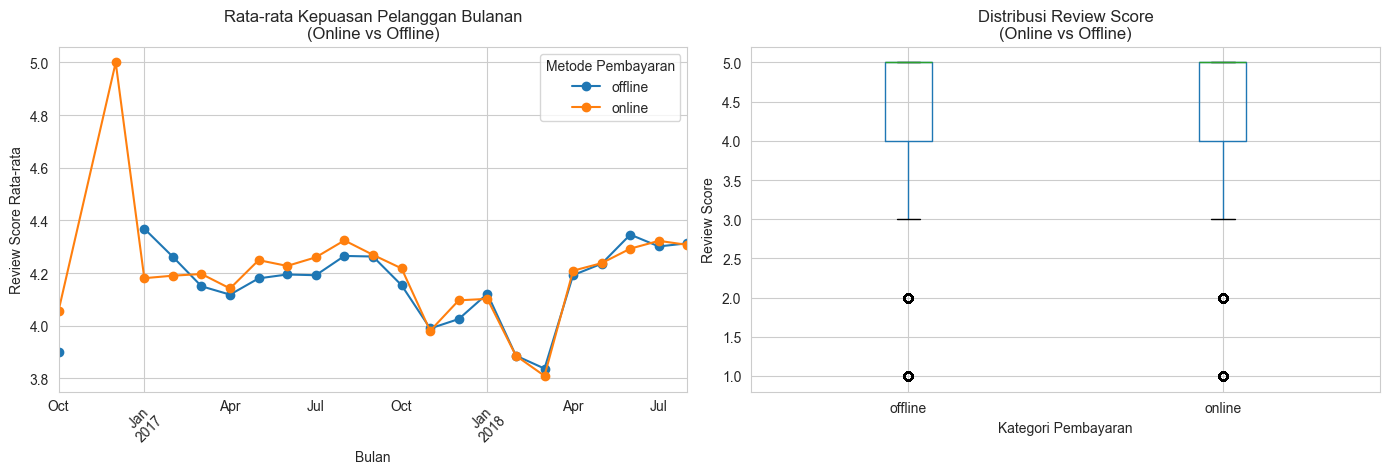

In [61]:
# 7. Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Rata-rata kepuasan bulanan
monthly_satisfaction_pivot.plot(ax=axes[0], marker='o', linewidth=1.5)
axes[0].set_title('Rata-rata Kepuasan Pelanggan Bulanan\n(Online vs Offline)', fontsize=12)
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Review Score Rata-rata')
axes[0].legend(title='Metode Pembayaran')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Boxplot distribusi
df_analysis.boxplot(column='review_score', by='payment_category', ax=axes[1])
axes[1].set_title('Distribusi Review Score\n(Online vs Offline)')
axes[1].set_xlabel('Kategori Pembayaran')
axes[1].set_ylabel('Review Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Pertanyaan 2:

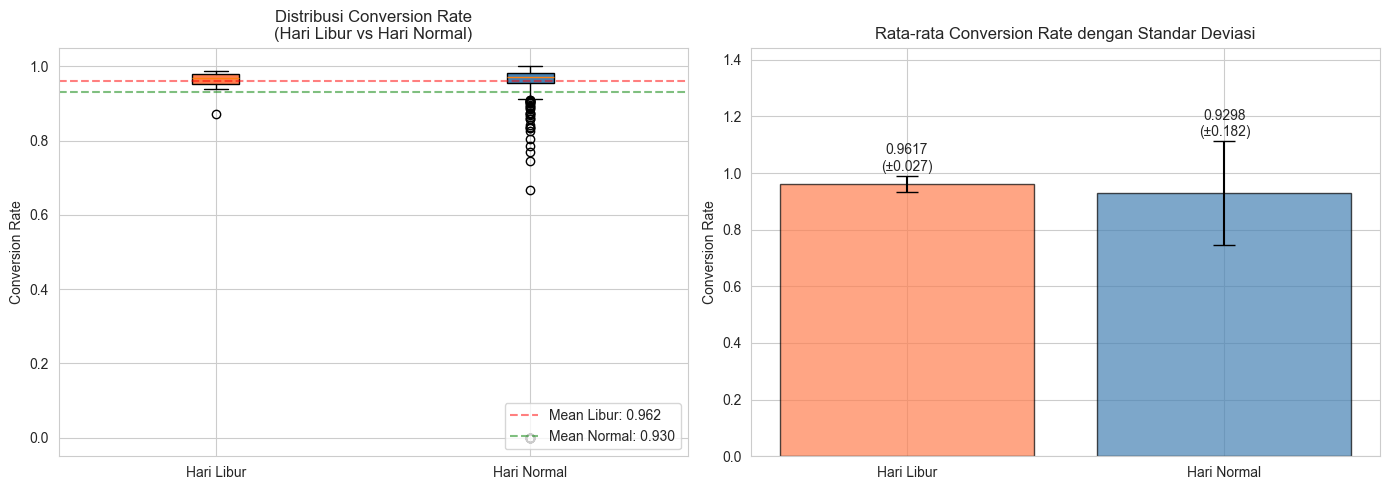


KESIMPULAN AKHIR
Perbedaan mean: 0.0319
p-value: 0.457854
Signifikansi (α=0.025): TIDAK SIGNIFIKAN


In [62]:
# 8. Visualisasi
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplot
data_boxplot = [holiday_conv, normal_conv]
labels = ['Hari Libur', 'Hari Normal']
bp = axes[0].boxplot(data_boxplot, labels=labels, patch_artist=True)
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')
axes[0].set_title('Distribusi Conversion Rate\n(Hari Libur vs Hari Normal)', fontsize=12)
axes[0].set_ylabel('Conversion Rate')
axes[0].axhline(y=holiday_conv.mean(), color='r', linestyle='--', alpha=0.5, label=f'Mean Libur: {holiday_conv.mean():.3f}')
axes[0].axhline(y=normal_conv.mean(), color='g', linestyle='--', alpha=0.5, label=f'Mean Normal: {normal_conv.mean():.3f}')
axes[0].legend(loc='lower right')

# Plot 2: Bar chart rata-rata dengan error bar
means = [holiday_conv.mean(), normal_conv.mean()]
stds = [holiday_conv.std(), normal_conv.std()]
x = np.arange(len(labels))
bars = axes[1].bar(x, means, yerr=stds, capsize=8, color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Rata-rata Conversion Rate dengan Standar Deviasi', fontsize=12)
axes[1].set_ylabel('Conversion Rate')
axes[1].set_ylim(0, max(means) * 1.5)
for i, (v, s) in enumerate(zip(means, stds)):
    axes[1].text(i, v + s + 0.02, f'{v:.4f}\n(±{s:.3f})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print hasil akhir
print("\n" + "="*60)
print("KESIMPULAN AKHIR")
print("="*60)
print(f"Perbedaan mean: {abs(holiday_conv.mean() - normal_conv.mean()):.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Signifikansi (α=0.025): {'SIGNIFIKAN' if p_value <= 0.025 else 'TIDAK SIGNIFIKAN'}")

**Insight Eksplorasi:**
- Jika p-value ≤ 0.025: Terdapat perbedaan signifikan antara konversi hari libur vs hari normal
- Jika p-value > 0.025: Tidak ada perbedaan signifikan antara konversi hari libur vs hari normal

## Analisis Lanjutan (Opsional)

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

### Pertanyaan 1: Kepuasan Pelanggan Online vs Offline

| Metrik | Nilai |
|--------|-------|
| t-statistic | 1.1116 |
| p-value | 0.2663 |
| Threshold | ≤ 0.01 |
| **Hasil** | **TIDAK SIGNIFIKAN** |

**Kesimpulan:**
Tidak ada perbedaan signifikan antara kepuasan pelanggan metode pembayaran online vs offline. Metode pembayaran tidak memengaruhi tingkat kepuasan pelanggan secara statistik signifikan.

**Rekomendasi:**
- Fokus pada aspek lain untuk meningkatkan kepuasan (delivery, kualitas produk, customer service)
- Tidak perlu membedakan strategi pelayanan berdasarkan metode pembayaran

**Rencana Aksi:**
| No | Aksi | Priority | Target |
|----|------|----------|--------|
| 1 | Fokus pada kecepatan delivery sebagai faktor kepuasan utama | High | Kurangi avg delivery time |
| 2 | Tingkatkan kualitas packaging untuk semua metode pembayaran | Medium | Kurangi kerusakan barang |
| 3 | Buat customer service yang responsif untuk semua channel | Medium | Response time < 24 jam |
| 4 | Monitor review score per kategori produk | Low | Dashboard monitoring |

---

### Pertanyaan 2: Konversi Hari Libur vs Hari Kerja

| Metrik | Hari Libur | Hari Normal |
|--------|------------|-------------|
| Jumlah hari | 18 | 616 |
| Mean conversion rate | 0.9617 | 0.9298 |
| Std | 0.0272 | 0.1820 |
| p-value | **0.4579** | |
| Alpha | **0.025** | |
| **Hasil** | **TIDAK SIGNIFIKAN** | |

**Kesimpulan:**
Tidak ada perbedaan signifikan antara konversi transaksional hari libur vs hari kerja normal. Tingkat keberhasilan pesanan (delivery) tidak berbeda secara statistik.

**Rekomendasi:**
- Tidak perlu strategi khusus untuk periode hari libur
- Tetap jaga kualitas layanan karena conversion rate holiday lebih tinggi (0.96) tapi tidak signifikan secara statistik
- Fokus pada penurunan std (0.1820) untuk hari normal agar lebih konsisten

**Rencana Aksi:**
| No | Aksi | Priority | Target |
|----|------|----------|--------|
| 1 | Stabilkan proses delivery hari normal ( std 0.1820 tinggi) | High | Kurangi variability |
| 2 | Jaga kapasitas warehouse menjelang holiday | Medium | Stock adequacy |
| 3 | Sediakan customer support extra saat holiday | Medium | Coverage 24/7 |
| 4 | Analisis faktor yang menyebabkan conversion rate rendah di hari tertentu | Low | Root cause analysis |